# Análise Exploratória de Dados (EDA) — Câncer Cervical

**Dataset:** [Cervical Cancer (Risk Factors)](https://archive.ics.uci.edu/dataset/383/cervical+cancer+risk+factors) — UCI Machine Learning Repository

**Variável-alvo:** `Biopsy` (0 = biópsia negativa, 1 = biópsia positiva)

**Objetivo desta etapa:** entender os dados — sua estrutura, qualidade, distribuições e
possíveis relações com o risco de câncer cervical. Esta é **apenas a etapa de EDA**.
Tratamento de valores ausentes para modelagem, balanceamento de classes (ex.: SMOTE),
engenharia de atributos e treinamento de modelos ficarão para notebooks futuros.

Este notebook foi desenvolvido para rodar no **Google Colab**, usando apenas
`pandas`, `numpy`, `matplotlib`, `seaborn` e `scikit-learn`.


## 0. Configuração do ambiente

Importação das bibliotecas utilizadas ao longo da análise.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais padrão para os gráficos deste notebook
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

pd.set_option("display.max_columns", None)


### Carregamento do arquivo

O caminho abaixo assume que o notebook é executado a partir de `/notebooks/` (por
isso o prefixo `../`), referenciando `data/raw/...` na raiz do repositório. Se o
notebook estiver rodando no Google Colab e o arquivo não existir localmente, será
solicitado o upload manual do CSV.

In [2]:
CSV_PATH = "../data/raw/kag_risk_factors_cervical_cancer.csv"

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB and not os.path.exists(CSV_PATH):
    from google.colab import files
    print("Arquivo não encontrado localmente. Faça o upload do CSV do dataset:")
    uploaded = files.upload()
    CSV_PATH = list(uploaded.keys())[0]

print(f"Carregando dados de: {CSV_PATH}")


Carregando dados de: ../data/raw/kag_risk_factors_cervical_cancer.csv


## 1. Carregamento e Inspeção Inicial

O dataset original representa valores ausentes com o caractere `"?"`. Já no momento da
leitura, informamos isso ao `pandas` (`na_values="?"`) para que esses valores sejam
tratados corretamente como nulos (`NaN`), em vez de como texto.

In [3]:
df = pd.read_csv(CSV_PATH, na_values="?")

print(f"Shape do dataset: {df.shape[0]} linhas x {df.shape[1]} colunas")
df.head()


Shape do dataset: 858 linhas x 36 colunas


,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,IUD (years),STDs,STDs (number),STDs:condylomatosis,STDs:cervical condylomatosis,STDs:vaginal condylomatosis,STDs:vulvo-perineal condylomatosis,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,STDs:molluscum contagiosum,STDs:AIDS,STDs:HIV,STDs:Hepatitis B,STDs:HPV,STDs: Number of diagnosis,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,0,0,0,0
2,34,1.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0,0,0,0,0,0,0,0


### Tipos de dados e valores ausentes

Antes de qualquer correção, vamos olhar como o `pandas` interpretou cada coluna.

In [4]:
df.dtypes.to_frame(name="dtype")


,dtype
Age,int64
Number of sexual partners,float64
First sexual intercourse,float64
Num of pregnancies,float64
Smokes,float64
Smokes (years),float64
Smokes (packs/year),float64
Hormonal Contraceptives,float64
Hormonal Contraceptives (years),float64
IUD,float64


In [5]:
nulos = df.isnull().sum().sort_values(ascending=False)
percentual_nulos = (nulos / len(df) * 100).round(2)

resumo_nulos = pd.DataFrame({"qtd_nulos": nulos, "percentual_%": percentual_nulos})
resumo_nulos[resumo_nulos["qtd_nulos"] > 0]


,qtd_nulos,percentual_%
STDs: Time since last diagnosis,787,91.72
STDs: Time since first diagnosis,787,91.72
IUD,117,13.64
IUD (years),117,13.64
Hormonal Contraceptives,108,12.59
Hormonal Contraceptives (years),108,12.59
STDs:pelvic inflammatory disease,105,12.24
STDs:vulvo-perineal condylomatosis,105,12.24
STDs:HPV,105,12.24
STDs:Hepatitis B,105,12.24


**O que os números mostram:**

- Duas colunas (`STDs: Time since first diagnosis` e `STDs: Time since last
  diagnosis`) têm mais de 90% de valores ausentes — praticamente não têm informação
  aproveitável no formato atual.
- Um segundo grupo de colunas (as relacionadas a `STDs`, `Number of sexual partners`,
  `First sexual intercourse`, `Num of pregnancies`, `Smokes`, `Hormonal
  Contraceptives` e `IUD`) tem entre ~1% e ~14% de valores ausentes — perdas pontuais,
  provavelmente por perguntas não respondidas no questionário original.
- A decisão sobre **o que fazer** com esses nulos (remover, imputar, etc.) será
  tomada na etapa de pré-processamento — aqui o objetivo é apenas diagnosticar.

### Correção de tipos de dados

Colunas que representam contagens, anos ou indicadores binários foram lidas como
`object` por causa do `"?"` no meio dos dados numéricos. Após substituir `"?"` por
`NaN` na leitura, convertemos explicitamente essas colunas para tipo numérico.

In [6]:
colunas_objeto = df.select_dtypes(include="object").columns.tolist()
print("Colunas ainda como 'object' após a leitura:")
print(colunas_objeto)


Colunas ainda como 'object' após a leitura:
[]


In [7]:
# Todas as colunas deste dataset são, por natureza, numéricas (contagens, anos,
# indicadores 0/1). Convertendo qualquer coluna 'object' restante para numérico.
for coluna in colunas_objeto:
    df[coluna] = pd.to_numeric(df[coluna], errors="coerce")

print("Tipos de dados após a correção:")
df.dtypes.value_counts()


Tipos de dados após a correção:


float64    26
int64      10
Name: count, dtype: int64

### Organização das variáveis por natureza

Para facilitar a análise, separamos as colunas em dois grupos:

- **Numéricas contínuas/discretas**: idade, quantidade de parceiros, anos de uso de
  algum método, etc.
- **Binárias/categóricas (0/1)**: indicadores de sim/não, como tabagismo, uso de
  contraceptivo, presença de DST e resultados de exames.

In [8]:
colunas_numericas = [
    "Age",
    "Number of sexual partners",
    "First sexual intercourse",
    "Num of pregnancies",
    "Smokes (years)",
    "Smokes (packs/year)",
    "Hormonal Contraceptives (years)",
    "IUD (years)",
    "STDs (number)",
    "STDs: Number of diagnosis",
    "STDs: Time since first diagnosis",
    "STDs: Time since last diagnosis",
]

colunas_binarias = [
    "Smokes",
    "Hormonal Contraceptives",
    "IUD",
    "STDs",
    "STDs:condylomatosis",
    "STDs:cervical condylomatosis",
    "STDs:vaginal condylomatosis",
    "STDs:vulvo-perineal condylomatosis",
    "STDs:syphilis",
    "STDs:pelvic inflammatory disease",
    "STDs:genital herpes",
    "STDs:molluscum contagiosum",
    "STDs:AIDS",
    "STDs:HIV",
    "STDs:Hepatitis B",
    "STDs:HPV",
    "Dx:Cancer",
    "Dx:CIN",
    "Dx:HPV",
    "Dx",
    "Hinselmann",
    "Schiller",
    "Citology",
    "Biopsy",
]

# Confere que classificamos todas as colunas do dataset
assert set(colunas_numericas + colunas_binarias) == set(df.columns)
print("Variáveis numéricas:", len(colunas_numericas))
print("Variáveis binárias/categóricas:", len(colunas_binarias))


Variáveis numéricas: 12
Variáveis binárias/categóricas: 24


## 2. Estatísticas Descritivas

### Variáveis numéricas

In [9]:
df[colunas_numericas].describe().T


,count,mean,std,min,25%,50%,75%,max
Age,858.0,26.820513,8.497948,13.0,20.0,25.0,32.0,84.0
Number of sexual partners,832.0,2.527644,1.667760,1.0,2.0,2.0,3.0,28.0
First sexual intercourse,851.0,16.995300,2.803355,10.0,15.0,17.0,18.0,32.0
Num of pregnancies,802.0,2.275561,1.447414,0.0,1.0,2.0,3.0,11.0
Smokes (years),845.0,1.219721,4.089017,0.0,0.0,0.0,0.0,37.0
Smokes (packs/year),845.0,0.453144,2.226610,0.0,0.0,0.0,0.0,37.0
Hormonal Contraceptives (years),750.0,2.256419,3.764254,0.0,0.0,0.5,3.0,30.0
IUD (years),741.0,0.514804,1.943089,0.0,0.0,0.0,0.0,19.0
STDs (number),753.0,0.176627,0.561993,0.0,0.0,0.0,0.0,4.0
STDs: Number of diagnosis,858.0,0.087413,0.302545,0.0,0.0,0.0,0.0,3.0


**Leitura dos números:**

- `Age` varia de adolescentes até pacientes acima dos 80 anos, com média em torno dos
  27 anos — a maior parte das pacientes é jovem/adulta.
- `Number of sexual partners` e `Num of pregnancies` têm médias baixas, mas valores
  máximos bem mais altos que a mediana, indicando **assimetria à direita** (poucas
  pacientes com valores muito altos puxam a média para cima).
- As colunas de "anos de uso" (`Smokes (years)`, `Hormonal Contraceptives (years)`,
  `IUD (years)`) têm mediana igual a 0 — ou seja, mais da metade das pacientes nunca
  fumou ou nunca usou esses métodos, o que é coerente com colunas binárias
  correspondentes (`Smokes`, `Hormonal Contraceptives`, `IUD`) predominantemente
  iguais a 0.
- `STDs: Time since first/last diagnosis` têm poucas observações válidas (coerente
  com o alto percentual de nulos visto antes), então suas estatísticas devem ser
  interpretadas com cautela.

### Variáveis binárias/categóricas

Para variáveis 0/1, o `describe()` mostra a média, que pode ser lida diretamente como a **proporção de pacientes com valor igual a 1** (ex.: proporção de fumantes, proporção de casos positivos em cada exame).

In [10]:
resumo_binarias = df[colunas_binarias].describe().T
resumo_binarias["proporcao_positivos_%"] = (resumo_binarias["mean"] * 100).round(2)
resumo_binarias[["count", "mean", "proporcao_positivos_%"]].sort_values(
    "proporcao_positivos_%", ascending=False
)


,count,mean,proporcao_positivos_%
Hormonal Contraceptives,750.0,0.641333,64.13
Smokes,845.0,0.145562,14.56
IUD,741.0,0.112011,11.20
STDs,753.0,0.104914,10.49
Schiller,858.0,0.086247,8.62
Biopsy,858.0,0.064103,6.41
STDs:condylomatosis,753.0,0.058433,5.84
STDs:vulvo-perineal condylomatosis,753.0,0.057105,5.71
Citology,858.0,0.051282,5.13
Hinselmann,858.0,0.040793,4.08


**Leitura dos números:**

- A variável-alvo `Biopsy` tem uma proporção pequena de casos positivos (poucos por
  cento da amostra) — já é um primeiro sinal de que as classes são **desbalanceadas**,
  algo que exploraremos visualmente a seguir e que será tratado na etapa de
  pré-processamento.
- `Hormonal Contraceptives` tem uma proporção considerável de "sim", enquanto `IUD` e
  `Smokes` são bem menos frequentes.
- A maioria das DSTs específicas (`STDs:syphilis`, `STDs:HIV`, `STDs:HPV`, etc.)
  aparece em uma fração muito pequena das pacientes — o que é esperado
  epidemiologicamente, mas também significa poucos exemplos positivos para o modelo
  aprender no futuro.
- Os exames `Hinselmann`, `Schiller`, `Citology` e o próprio `Biopsy` têm proporções
  de positivos parecidas entre si — faz sentido, já que todos são formas diferentes de
  investigar a mesma condição (lesões cervicais).

## 3. Visualizações Relevantes

### 3.1 Distribuição da variável-alvo (`Biopsy`)

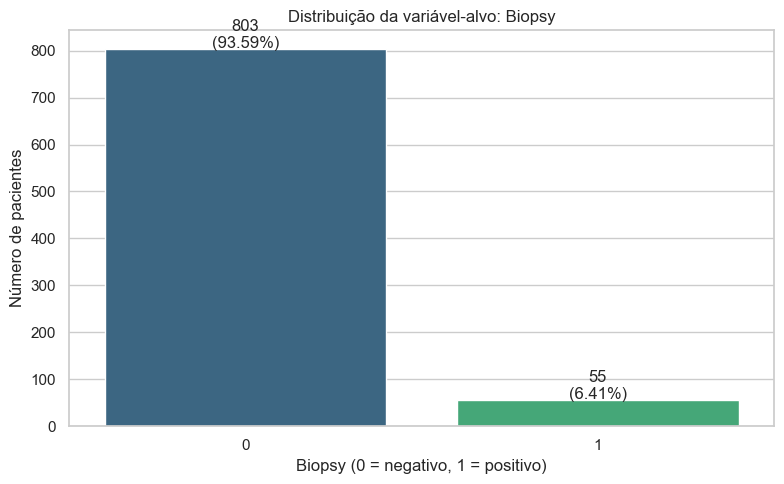

In [11]:
contagem_biopsy = df["Biopsy"].value_counts().sort_index()
percentual_biopsy = (contagem_biopsy / len(df) * 100).round(2)

fig, ax = plt.subplots()
sns.barplot(
    x=contagem_biopsy.index.astype(str),
    y=contagem_biopsy.values,
    hue=contagem_biopsy.index.astype(str),
    legend=False,
    ax=ax,
    palette="viridis",
)
ax.set_xlabel("Biopsy (0 = negativo, 1 = positivo)")
ax.set_ylabel("Número de pacientes")
ax.set_title("Distribuição da variável-alvo: Biopsy")

for i, valor in enumerate(contagem_biopsy.values):
    ax.text(i, valor + 2, f"{valor}\n({percentual_biopsy.iloc[i]}%)", ha="center")

plt.tight_layout()
plt.show()


**Interpretação:** as classes são fortemente desbalanceadas — a grande maioria das
pacientes tem biópsia negativa, e apenas uma pequena fração tem biópsia positiva. Isso
é comum em bases de triagem/diagnóstico (a doença é rara na população estudada), mas é
um ponto de atenção importante para a etapa de modelagem, já que um modelo ingênuo
poderia "acertar" a maioria das vezes apenas prevendo sempre a classe negativa. O
balanceamento de classes será tratado em uma etapa futura.

### 3.2 Distribuição das principais variáveis numéricas

Abaixo, histogramas e boxplots para as variáveis numéricas mais relevantes para o contexto clínico: idade, número de parceiros sexuais, idade na primeira relação sexual e número de gestações.

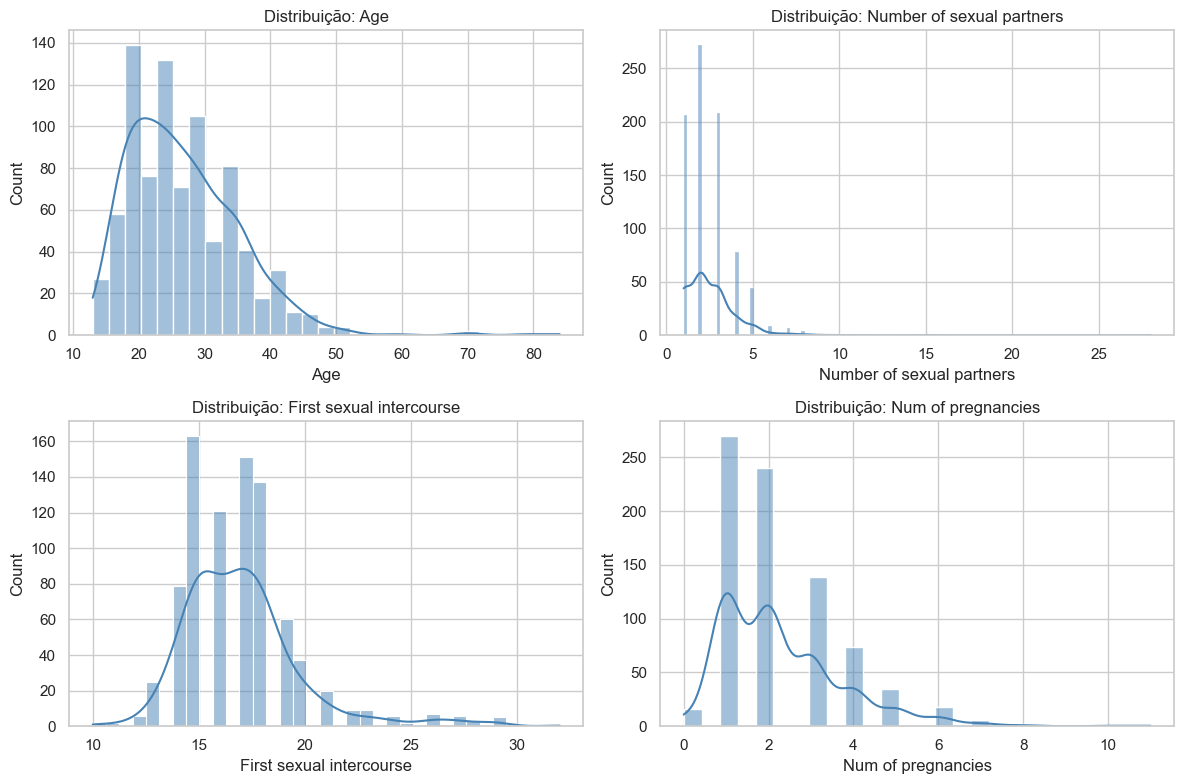

In [12]:
variaveis_destaque = [
    "Age",
    "Number of sexual partners",
    "First sexual intercourse",
    "Num of pregnancies",
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, coluna in zip(axes, variaveis_destaque):
    sns.histplot(df[coluna].dropna(), kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Distribuição: {coluna}")
    ax.set_xlabel(coluna)

plt.tight_layout()
plt.show()


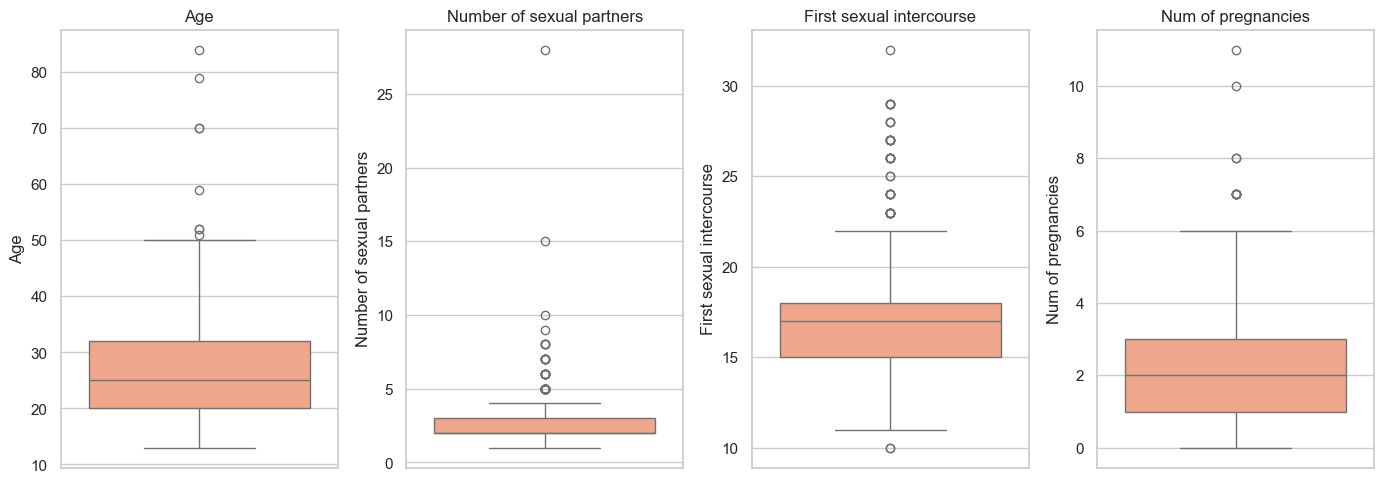

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(14, 5))

for ax, coluna in zip(axes, variaveis_destaque):
    sns.boxplot(y=df[coluna].dropna(), ax=ax, color="lightsalmon")
    ax.set_title(coluna)

plt.tight_layout()
plt.show()


**Interpretação:**

- `Age`: distribuição concentrada entre ~18 e 40 anos, com uma cauda longa até
  pacientes mais velhas — poucos outliers acima dos 60-70 anos.
- `Number of sexual partners`: fortemente concentrada em valores baixos (1 a 3), com
  alguns outliers de pacientes com número bem mais alto de parceiros — o boxplot
  evidencia esses pontos fora da "caixa".
- `First sexual intercourse`: concentrada entre 15 e 20 anos, com poucos casos muito
  abaixo ou acima dessa faixa (outliers que merecem checagem de consistência, ex.:
  idade de início muito baixa).
- `Num of pregnancies`: a maior parte das pacientes teve entre 1 e 3 gestações, com
  cauda longa para valores mais altos.

Esses outliers não serão removidos nesta etapa — são apenas observados aqui como
características da base.

### 3.3 Matriz de correlação

Correlação (Pearson) entre todas as variáveis numéricas e binárias, incluindo a variável-alvo `Biopsy`.

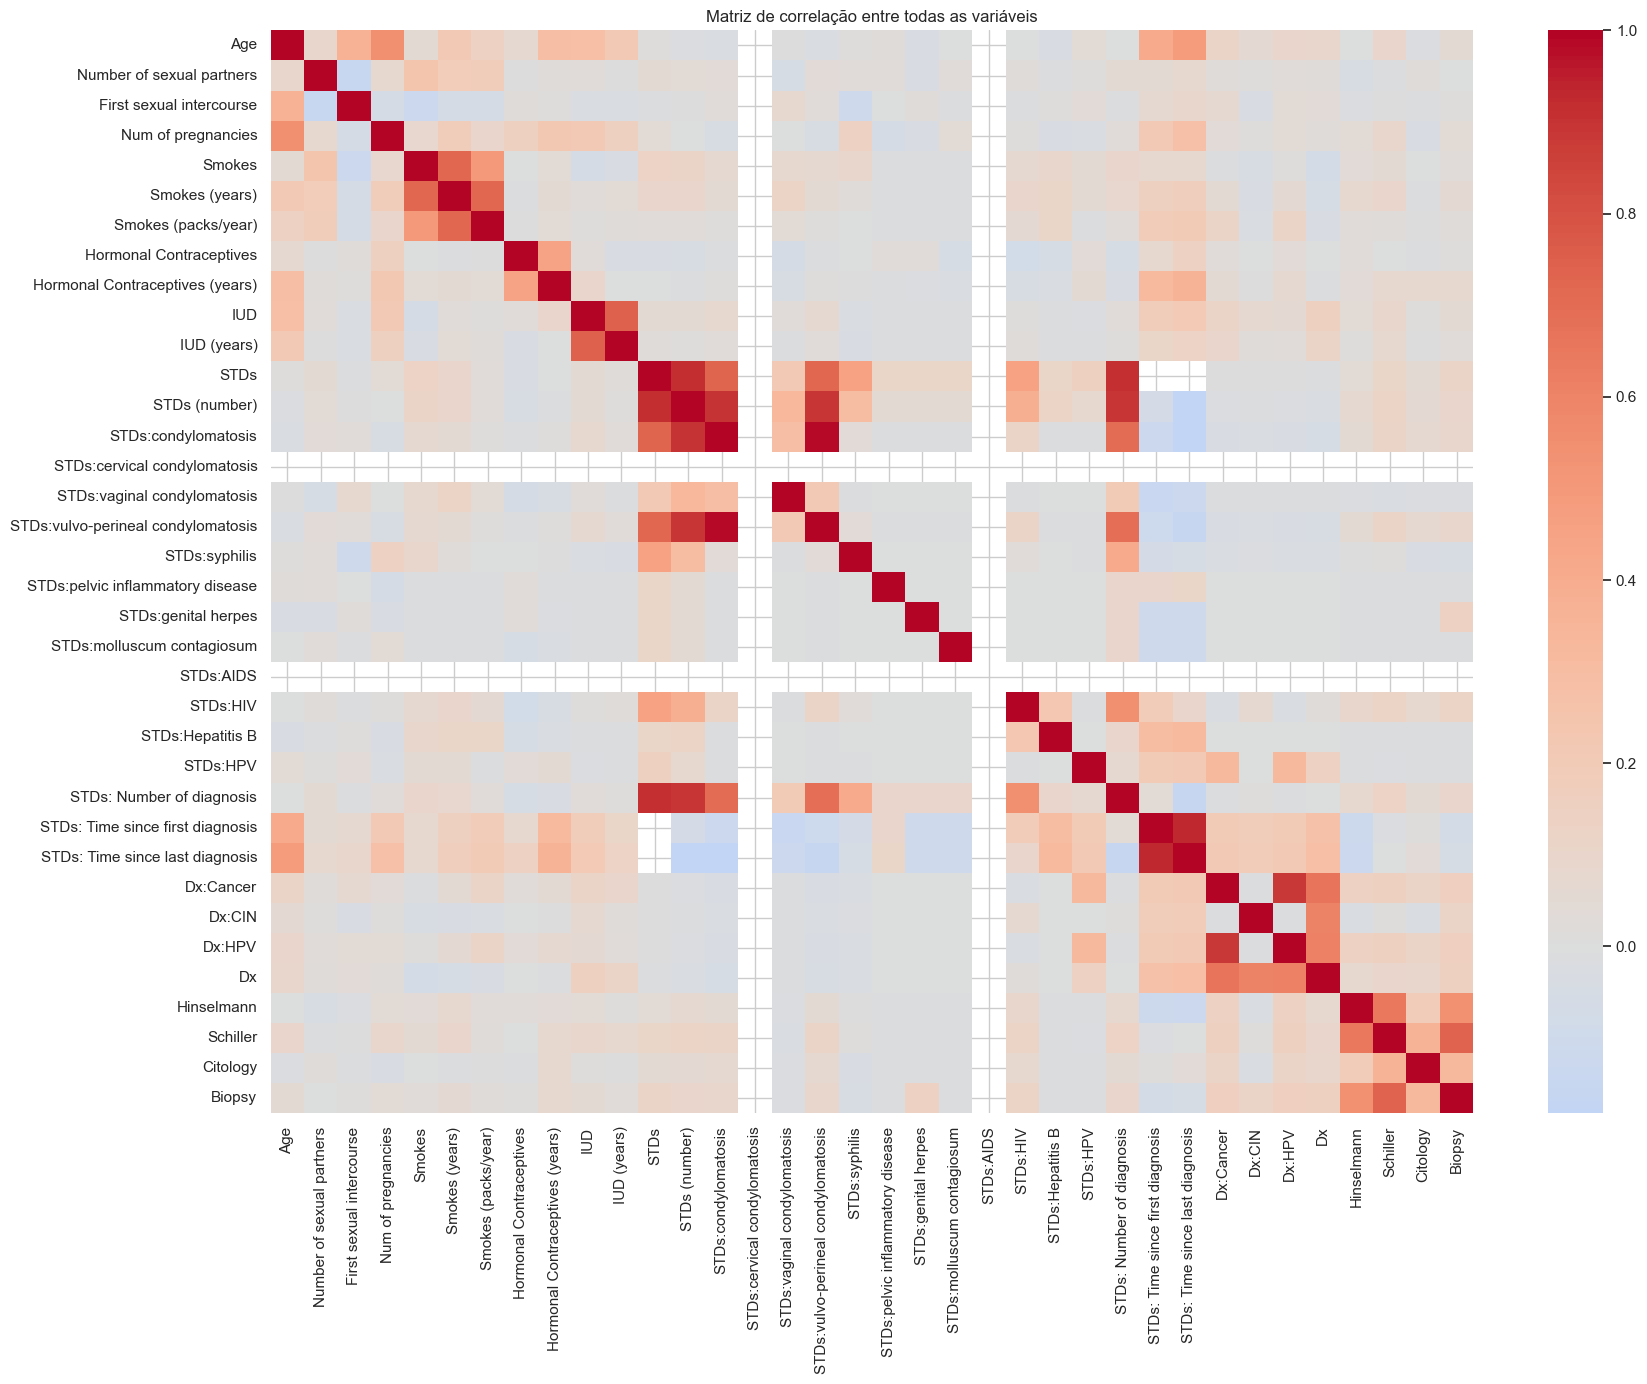

In [14]:
matriz_corr = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(matriz_corr, cmap="coolwarm", center=0, annot=False, ax=ax)
ax.set_title("Matriz de correlação entre todas as variáveis")
plt.tight_layout()
plt.show()


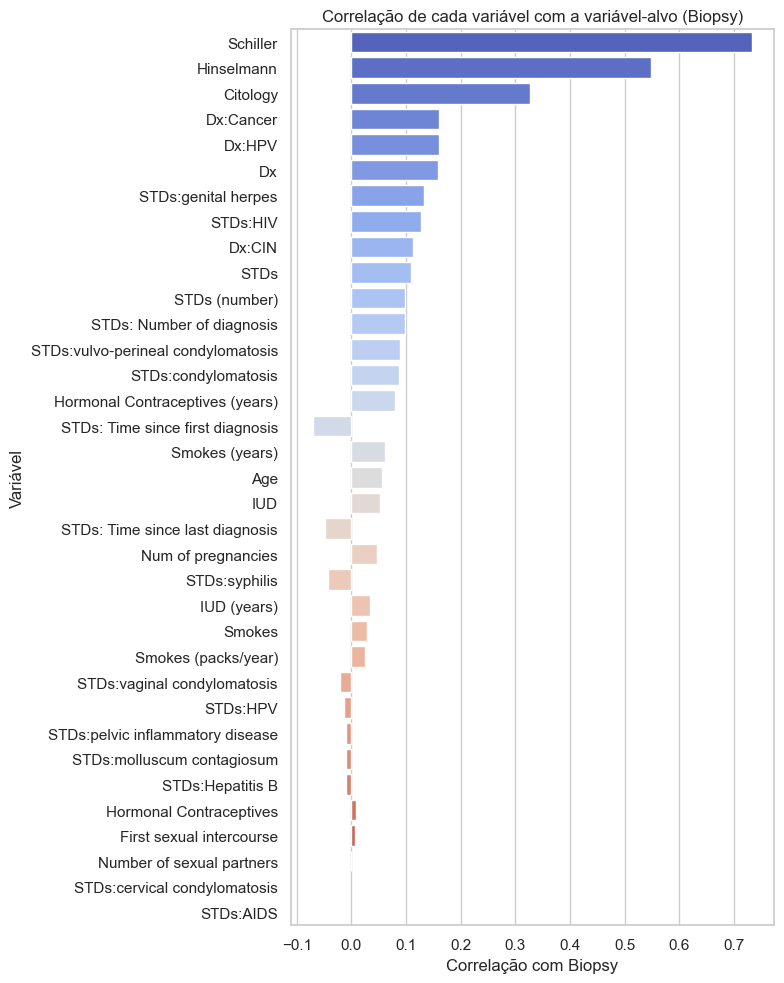

,correlacao_com_biopsy
Schiller,0.733204
Hinselmann,0.547417
Citology,0.327466
Dx:Cancer,0.160905
Dx:HPV,0.160905
Dx,0.157607
STDs:genital herpes,0.132526
STDs:HIV,0.126880
Dx:CIN,0.113172
STDs,0.109099


In [15]:
corr_com_target = (
    matriz_corr["Biopsy"]
    .drop("Biopsy")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 10))
sns.barplot(
    x=corr_com_target.values,
    y=corr_com_target.index,
    hue=corr_com_target.index,
    legend=False,
    ax=ax,
    palette="coolwarm",
)
ax.set_xlabel("Correlação com Biopsy")
ax.set_ylabel("Variável")
ax.set_title("Correlação de cada variável com a variável-alvo (Biopsy)")
plt.tight_layout()
plt.show()

corr_com_target.to_frame(name="correlacao_com_biopsy")


**Interpretação:**

- As correlações mais fortes com `Biopsy` são justamente os outros exames de rastreio
  (`Schiller`, `Hinselmann`, `Citology`) e os diagnósticos (`Dx`, `Dx:Cancer`,
  `Dx:CIN`, `Dx:HPV`). Isso é esperado: todos medem, de formas diferentes, a mesma
  condição clínica (lesão cervical). É importante ter isso em mente para a próxima
  etapa — usar esses exames como variáveis preditoras pode ser um "vazamento de
  informação" (data leakage), já que na prática eles não estariam disponíveis antes do
  diagnóstico.
- Entre os fatores de risco "comportamentais/clínicos" (idade, contracepção,
  tabagismo, DSTs), as correlações individuais com `Biopsy` são bem mais fracas —
  nenhuma variável isolada explica sozinha o resultado da biópsia, o que é coerente
  com a literatura: o risco de câncer cervical é multifatorial.
- A matriz completa também mostra correlações fortes entre variáveis relacionadas por
  construção (ex.: `Smokes` e `Smokes (years)`, ou `STDs` e as colunas específicas de
  cada DST) — algo natural, já que umas derivam das outras.

## 4. Padrões Relacionados à Saúde e Segurança Feminina

Nesta seção, olhamos mais de perto para fatores de risco frequentemente discutidos na
literatura sobre câncer cervical: uso de contraceptivos hormonais/DIU, tabagismo e
presença de DSTs — sempre em relação ao diagnóstico (`Biopsy`).

### 4.1 Contraceptivos hormonais e DIU x Diagnóstico

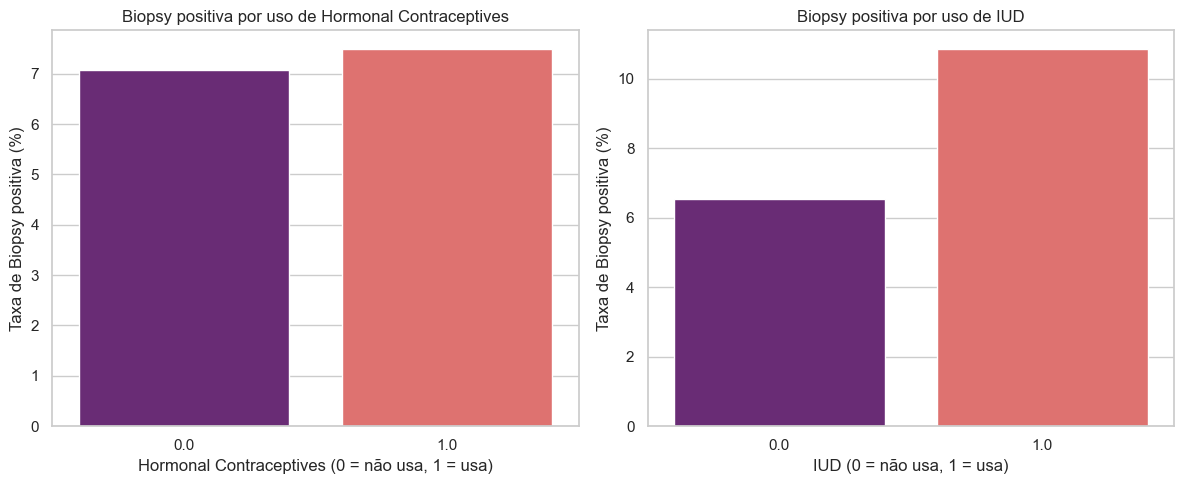

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, coluna in zip(axes, ["Hormonal Contraceptives", "IUD"]):
    taxa = df.groupby(coluna)["Biopsy"].mean() * 100
    sns.barplot(
        x=taxa.index.astype(str),
        y=taxa.values,
        hue=taxa.index.astype(str),
        legend=False,
        ax=ax,
        palette="magma",
    )
    ax.set_xlabel(f"{coluna} (0 = não usa, 1 = usa)")
    ax.set_ylabel("Taxa de Biopsy positiva (%)")
    ax.set_title(f"Biopsy positiva por uso de {coluna}")

plt.tight_layout()
plt.show()


**Interpretação:** comparamos a taxa de biópsias positivas entre quem usa e quem não
usa cada método. Se as barras forem parecidas entre 0 e 1, isso sugere que, nesta
amostra, o uso do método não está fortemente associado ao resultado da biópsia. Vale
lembrar que a literatura aponta uso prolongado de contraceptivos hormonais como fator
de risco — por isso também vale observar `Hormonal Contraceptives (years)`, e não
apenas o indicador binário de uso.

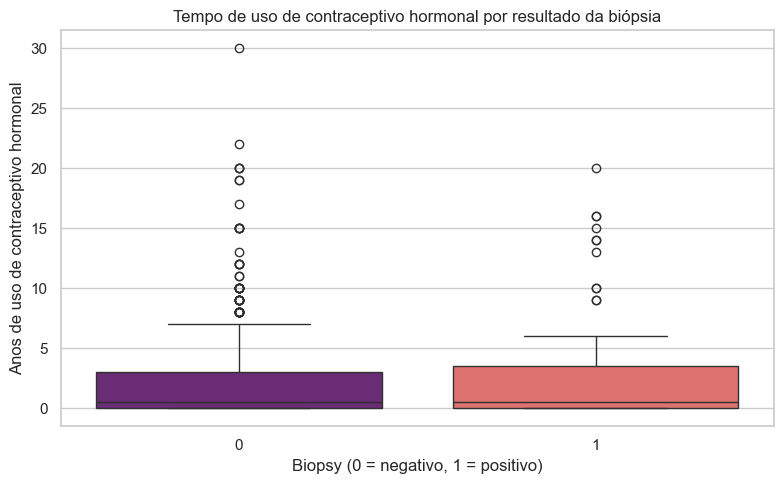

In [17]:
fig, ax = plt.subplots()
sns.boxplot(x="Biopsy", y="Hormonal Contraceptives (years)", data=df, hue="Biopsy", legend=False, palette="magma", ax=ax)
ax.set_xlabel("Biopsy (0 = negativo, 1 = positivo)")
ax.set_ylabel("Anos de uso de contraceptivo hormonal")
ax.set_title("Tempo de uso de contraceptivo hormonal por resultado da biópsia")
plt.tight_layout()
plt.show()


**Interpretação:** aqui observamos se pacientes com biópsia positiva tendem a ter mais anos de uso de contraceptivo hormonal do que as com biópsia negativa — uma mediana ou distribuição mais alta no grupo positivo reforçaria a hipótese de que o tempo de exposição (não apenas o uso) importa.

### 4.2 Tabagismo x Diagnóstico

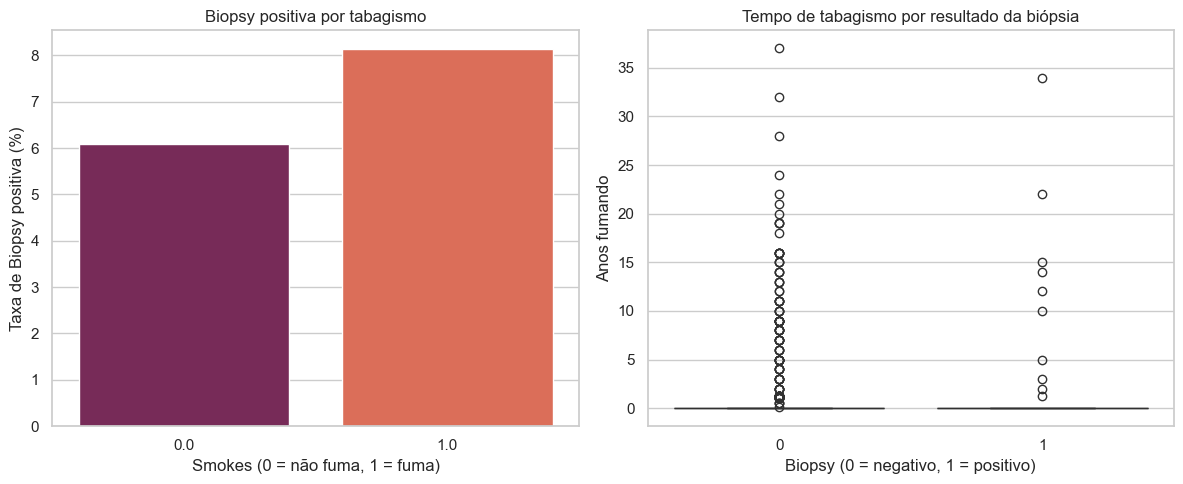

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

taxa_fumo = df.groupby("Smokes")["Biopsy"].mean() * 100
sns.barplot(
    x=taxa_fumo.index.astype(str),
    y=taxa_fumo.values,
    hue=taxa_fumo.index.astype(str),
    legend=False,
    ax=axes[0],
    palette="rocket",
)
axes[0].set_xlabel("Smokes (0 = não fuma, 1 = fuma)")
axes[0].set_ylabel("Taxa de Biopsy positiva (%)")
axes[0].set_title("Biopsy positiva por tabagismo")

sns.boxplot(x="Biopsy", y="Smokes (years)", data=df, hue="Biopsy", legend=False, palette="rocket", ax=axes[1])
axes[1].set_xlabel("Biopsy (0 = negativo, 1 = positivo)")
axes[1].set_ylabel("Anos fumando")
axes[1].set_title("Tempo de tabagismo por resultado da biópsia")

plt.tight_layout()
plt.show()


**Interpretação:** o tabagismo é um fator de risco bem documentado na literatura
médica para câncer cervical. Aqui comparamos tanto a proporção de biópsias positivas
entre fumantes e não fumantes quanto o tempo de exposição ao cigarro (`Smokes
(years)`) entre os dois grupos de diagnóstico. Como o número de fumantes na amostra é
relativamente pequeno, essa relação deve ser interpretada com cautela — poucos casos
positivos entre fumantes já geram bastante variação nas taxas observadas.

### 4.3 DSTs (STDs) x Diagnóstico

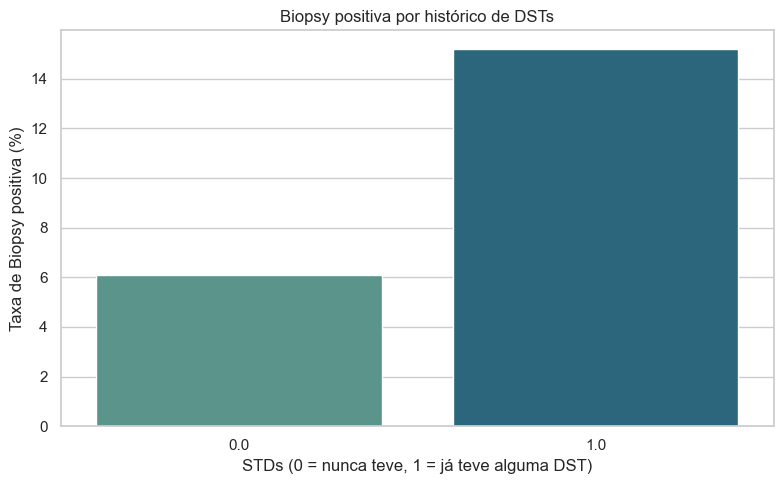

In [19]:
taxa_stds = df.groupby("STDs")["Biopsy"].mean() * 100

fig, ax = plt.subplots()
sns.barplot(
    x=taxa_stds.index.astype(str),
    y=taxa_stds.values,
    hue=taxa_stds.index.astype(str),
    legend=False,
    ax=ax,
    palette="crest",
)
ax.set_xlabel("STDs (0 = nunca teve, 1 = já teve alguma DST)")
ax.set_ylabel("Taxa de Biopsy positiva (%)")
ax.set_title("Biopsy positiva por histórico de DSTs")
plt.tight_layout()
plt.show()


In [20]:
colunas_stds_especificas = [c for c in colunas_binarias if c.startswith("STDs:")]

taxa_por_dst = pd.DataFrame({
    "prevalencia_%": (df[colunas_stds_especificas].mean() * 100).round(2),
    "taxa_biopsy_positiva_quando_presente_%": [
        (df.loc[df[c] == 1, "Biopsy"].mean() * 100).round(2) if df[c].sum() > 0 else np.nan
        for c in colunas_stds_especificas
    ],
})

taxa_por_dst.sort_values("taxa_biopsy_positiva_quando_presente_%", ascending=False)


,prevalencia_%,taxa_biopsy_positiva_quando_presente_%
STDs:genital herpes,0.13,100.00
STDs:HIV,2.39,27.78
STDs:vulvo-perineal condylomatosis,5.71,16.28
STDs:condylomatosis,5.84,15.91
STDs:vaginal condylomatosis,0.53,0.00
STDs:syphilis,2.39,0.00
STDs:pelvic inflammatory disease,0.13,0.00
STDs:molluscum contagiosum,0.13,0.00
STDs:Hepatitis B,0.13,0.00
STDs:HPV,0.27,0.00


**Interpretação:** o histórico de DSTs em geral (`STDs`) já mostra uma taxa de
biópsia positiva mais alta entre quem já teve alguma DST, o que é coerente com o papel
conhecido de infecções sexualmente transmissíveis (especialmente HPV) no
desenvolvimento do câncer cervical. Ao olhar as DSTs específicas, é importante notar
que a **prevalência de cada uma é muito baixa** nesta amostra — então taxas
aparentemente altas em algumas DSTs específicas podem estar baseadas em poucas
pacientes, e não devem ser generalizadas sem cautela estatística.

### 4.4 Outros padrões de risco que se destacam

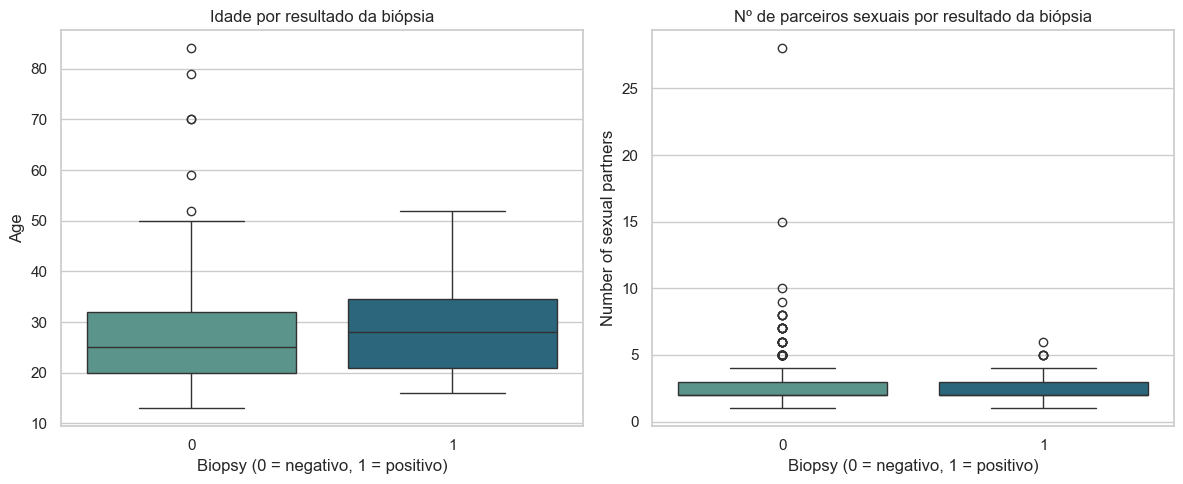

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x="Biopsy", y="Age", data=df, hue="Biopsy", legend=False, palette="crest", ax=axes[0])
axes[0].set_title("Idade por resultado da biópsia")
axes[0].set_xlabel("Biopsy (0 = negativo, 1 = positivo)")

sns.boxplot(x="Biopsy", y="Number of sexual partners", data=df, hue="Biopsy", legend=False, palette="crest", ax=axes[1])
axes[1].set_title("Nº de parceiros sexuais por resultado da biópsia")
axes[1].set_xlabel("Biopsy (0 = negativo, 1 = positivo)")

plt.tight_layout()
plt.show()


**Interpretação:** comparando idade e número de parceiros sexuais entre os grupos de
diagnóstico, buscamos identificar se algum desses fatores de exposição isoladamente
já desloca a distribuição no grupo positivo. Combinado com a análise de correlação da
seção 3.3, esperamos reforçar a conclusão de que **nenhum fator de risco isolado é
fortemente determinante** — o risco de biópsia positiva parece ser resultado da
combinação de múltiplos fatores (idade, comportamento sexual, tabagismo, histórico de
DSTs), o que é consistente com o conhecimento médico sobre a doença.

## 5. Síntese da Análise Exploratória

Principais pontos observados nesta EDA:

1. **Qualidade dos dados:** há valores ausentes em diversas colunas, com destaque para
   `STDs: Time since first diagnosis` e `STDs: Time since last diagnosis`, que têm
   mais de 90% de dados faltantes. As demais colunas com nulos têm perdas pontuais
   (na casa de 1% a 14%).
2. **Classes desbalanceadas:** a variável-alvo `Biopsy` tem poucos casos positivos em
   relação ao total — um ponto central a ser tratado na etapa de pré-processamento
   (ex.: técnicas de balanceamento).
3. **Risco de vazamento de dados (data leakage):** os exames `Hinselmann`, `Schiller`,
   `Citology` e os campos `Dx*` são fortemente correlacionados com `Biopsy` porque
   investigam a mesma condição clínica. Isso precisa ser considerado com cuidado ao
   definir quais variáveis serão usadas como preditoras na etapa de modelagem.
4. **Fatores de risco comportamentais/clínicos:** tabagismo, uso de contraceptivos
   hormonais/DIU e histórico de DSTs mostram alguma associação com o resultado da
   biópsia, mas nenhum de forma isolada e fortemente determinante — reforçando a
   natureza multifatorial do risco de câncer cervical.
5. **Distribuições assimétricas e outliers:** variáveis como número de parceiros
   sexuais e número de gestações têm caudas longas à direita, o que deverá ser
   considerado na etapa de pré-processamento (normalização/padronização, tratamento
   de outliers).

**Próximos passos (fora do escopo deste notebook):** tratamento de valores ausentes,
avaliação e mitigação do vazamento de dados entre exames, balanceamento de classes e
preparação das variáveis para modelagem preditiva.